# Analisis de Demanda Temporal y Oportunidades de Rentabilidad

**Dataset:** Coffee Store Sales | **Periodo:** Mar 2024 - Mar 2025

**Objetivo:** Identificar patrones de demanda por producto, dia de la semana y momento del dia. Derivar recomendaciones accionables de mix y promocion.

---

### Nota metodologica

| Problema | Version anterior |
|----------|-----------------|
| Variable dependiente | log(qty) en todos |
| Regresor principal | Dummies temporales exogenas |
| Control ano | Todos los productos |
| Codigo | Funcion reutilizable |



## 1. Setup e importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

WEEKDAY_ORDER = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
TOD_ORDER     = ["Morning", "Afternoon", "Night"]
SEASON_MAP    = {
    "Dec": "Winter", "Jan": "Winter", "Feb": "Winter",
    "Mar": "Spring", "Apr": "Spring", "May": "Spring",
    "Jun": "Summer", "Jul": "Summer", "Aug": "Summer",
    "Sep": "Autumn", "Oct": "Autumn", "Nov": "Autumn"
}
PRODUCT_COLORS = px.colors.qualitative.Set2

## 2. Carga y preparacion del dataset

In [2]:
df = pd.read_excel("/content/Coffe_sales.xlsx")
df["date"]       = pd.to_datetime(df["date"])
df["datetime"]   = pd.to_datetime(df["datetime"])
df["year"]       = df["date"].dt.year
df["season"]     = df["Month_name"].map(SEASON_MAP)
df["year_month"] = df["date"].dt.to_period("M")
df["Weekday"]     = pd.Categorical(df["Weekday"],     categories=WEEKDAY_ORDER, ordered=True)
df["Time_of_Day"] = pd.Categorical(df["Time_of_Day"], categories=TOD_ORDER,     ordered=True)

print(f"Registros: {len(df):,} | Productos: {df['coffee_name'].nunique()} | Periodo: {df['date'].min().date()} - {df['date'].max().date()}")
print("\nNulos:", df.isnull().sum()[df.isnull().sum() > 0].to_dict())
display(df[["money","hour_of_day"]].describe().round(2))
df.head()

Registros: 3,636 | Productos: 8 | Periodo: 2024-03-01 - 2025-03-23

Nulos: {'card': 89}


,money,hour_of_day
count,3636.00,3636.00
mean,31.75,14.17
std,4.92,4.23
min,18.12,6.00
25%,27.92,10.00
50%,32.82,14.00
75%,35.76,18.00
max,40.00,22.00


,date,datetime,hour_of_day,cash_type,card,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,year,season,year_month
0,2024-03-01,2024-03-01 10:15:50.520,10,card,ANON-0000-0000-0001,38.7,Latte,Morning,Fri,Mar,5,3,2024,Spring,2024-03
1,2024-03-01,2024-03-01 12:19:22.539,12,card,ANON-0000-0000-0002,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024,Spring,2024-03
2,2024-03-01,2024-03-01 12:20:18.089,12,card,ANON-0000-0000-0002,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024,Spring,2024-03
3,2024-03-01,2024-03-01 13:46:33.006,13,card,ANON-0000-0000-0003,28.9,Americano,Afternoon,Fri,Mar,5,3,2024,Spring,2024-03
4,2024-03-01,2024-03-01 13:48:14.626,13,card,ANON-0000-0000-0004,38.7,Latte,Afternoon,Fri,Mar,5,3,2024,Spring,2024-03


## 3. Analisis Exploratorio de Datos

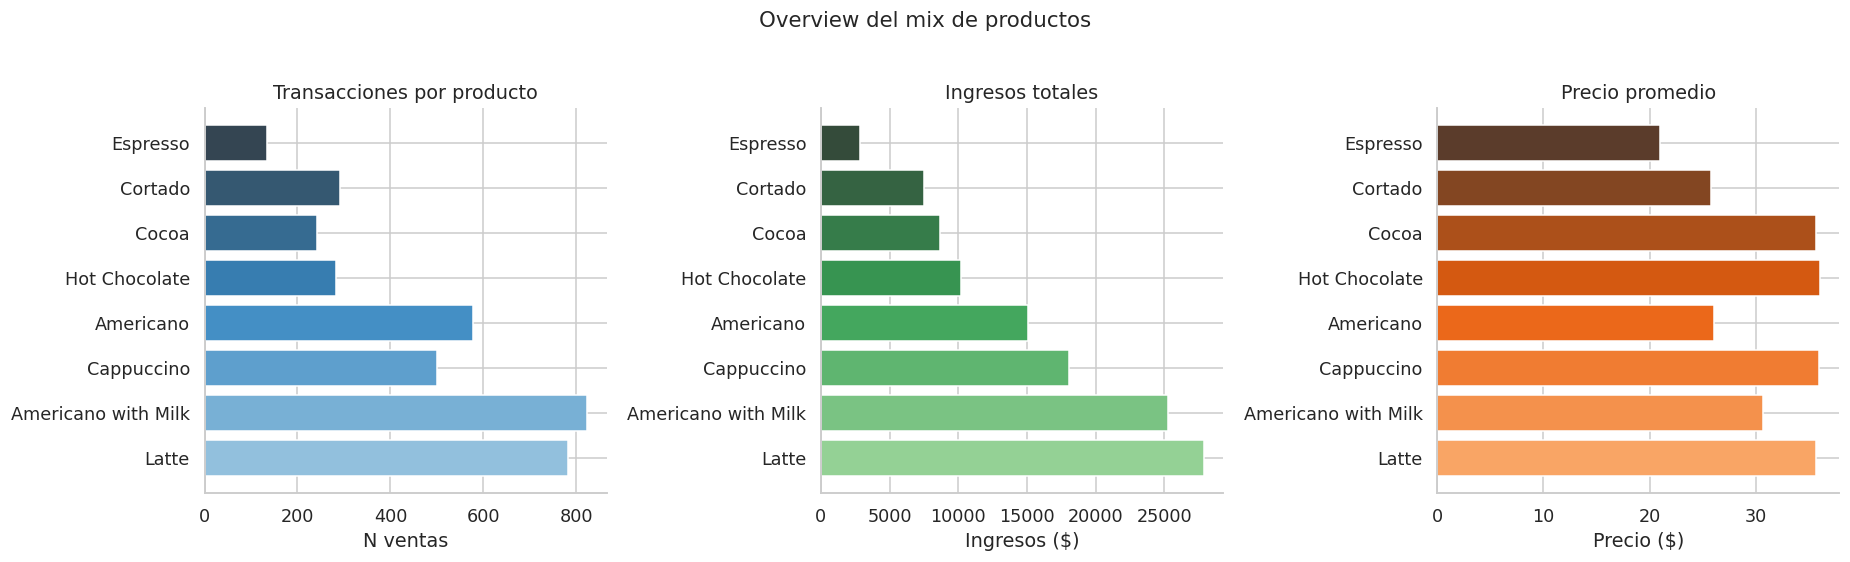

,coffee_name,qty,revenue,avg_price
0,Latte,782,27866.30,35.63
1,Americano with Milk,824,25269.12,30.67
2,Cappuccino,501,18034.14,36.00
3,Americano,578,15062.26,26.06
4,Hot Chocolate,282,10172.46,36.07
5,Cocoa,243,8678.16,35.71
6,Cortado,292,7534.86,25.80
7,Espresso,134,2814.28,21.00


In [3]:
product_stats = (
    df.groupby("coffee_name")
      .agg(qty=("money","count"), revenue=("money","sum"), avg_price=("money","mean"))
      .sort_values("revenue", ascending=False)
      .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].barh(product_stats["coffee_name"], product_stats["qty"],
             color=sns.color_palette("Blues_d", len(product_stats)))
axes[0].set_title("Transacciones por producto"); axes[0].set_xlabel("N ventas")

axes[1].barh(product_stats["coffee_name"], product_stats["revenue"],
             color=sns.color_palette("Greens_d", len(product_stats)))
axes[1].set_title("Ingresos totales"); axes[1].set_xlabel("Ingresos ($)")

axes[2].barh(product_stats["coffee_name"], product_stats["avg_price"],
             color=sns.color_palette("Oranges_d", len(product_stats)))
axes[2].set_title("Precio promedio"); axes[2].set_xlabel("Precio ($)")

plt.suptitle("Overview del mix de productos", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
display(product_stats.round(2))

## 4. Heatmaps: Demanda por Dia x Momento

Visualizacion clave ausente en la version anterior. Permite identificar de un vistazo
en que combinacion dia-horario cada producto vende mas o menos.


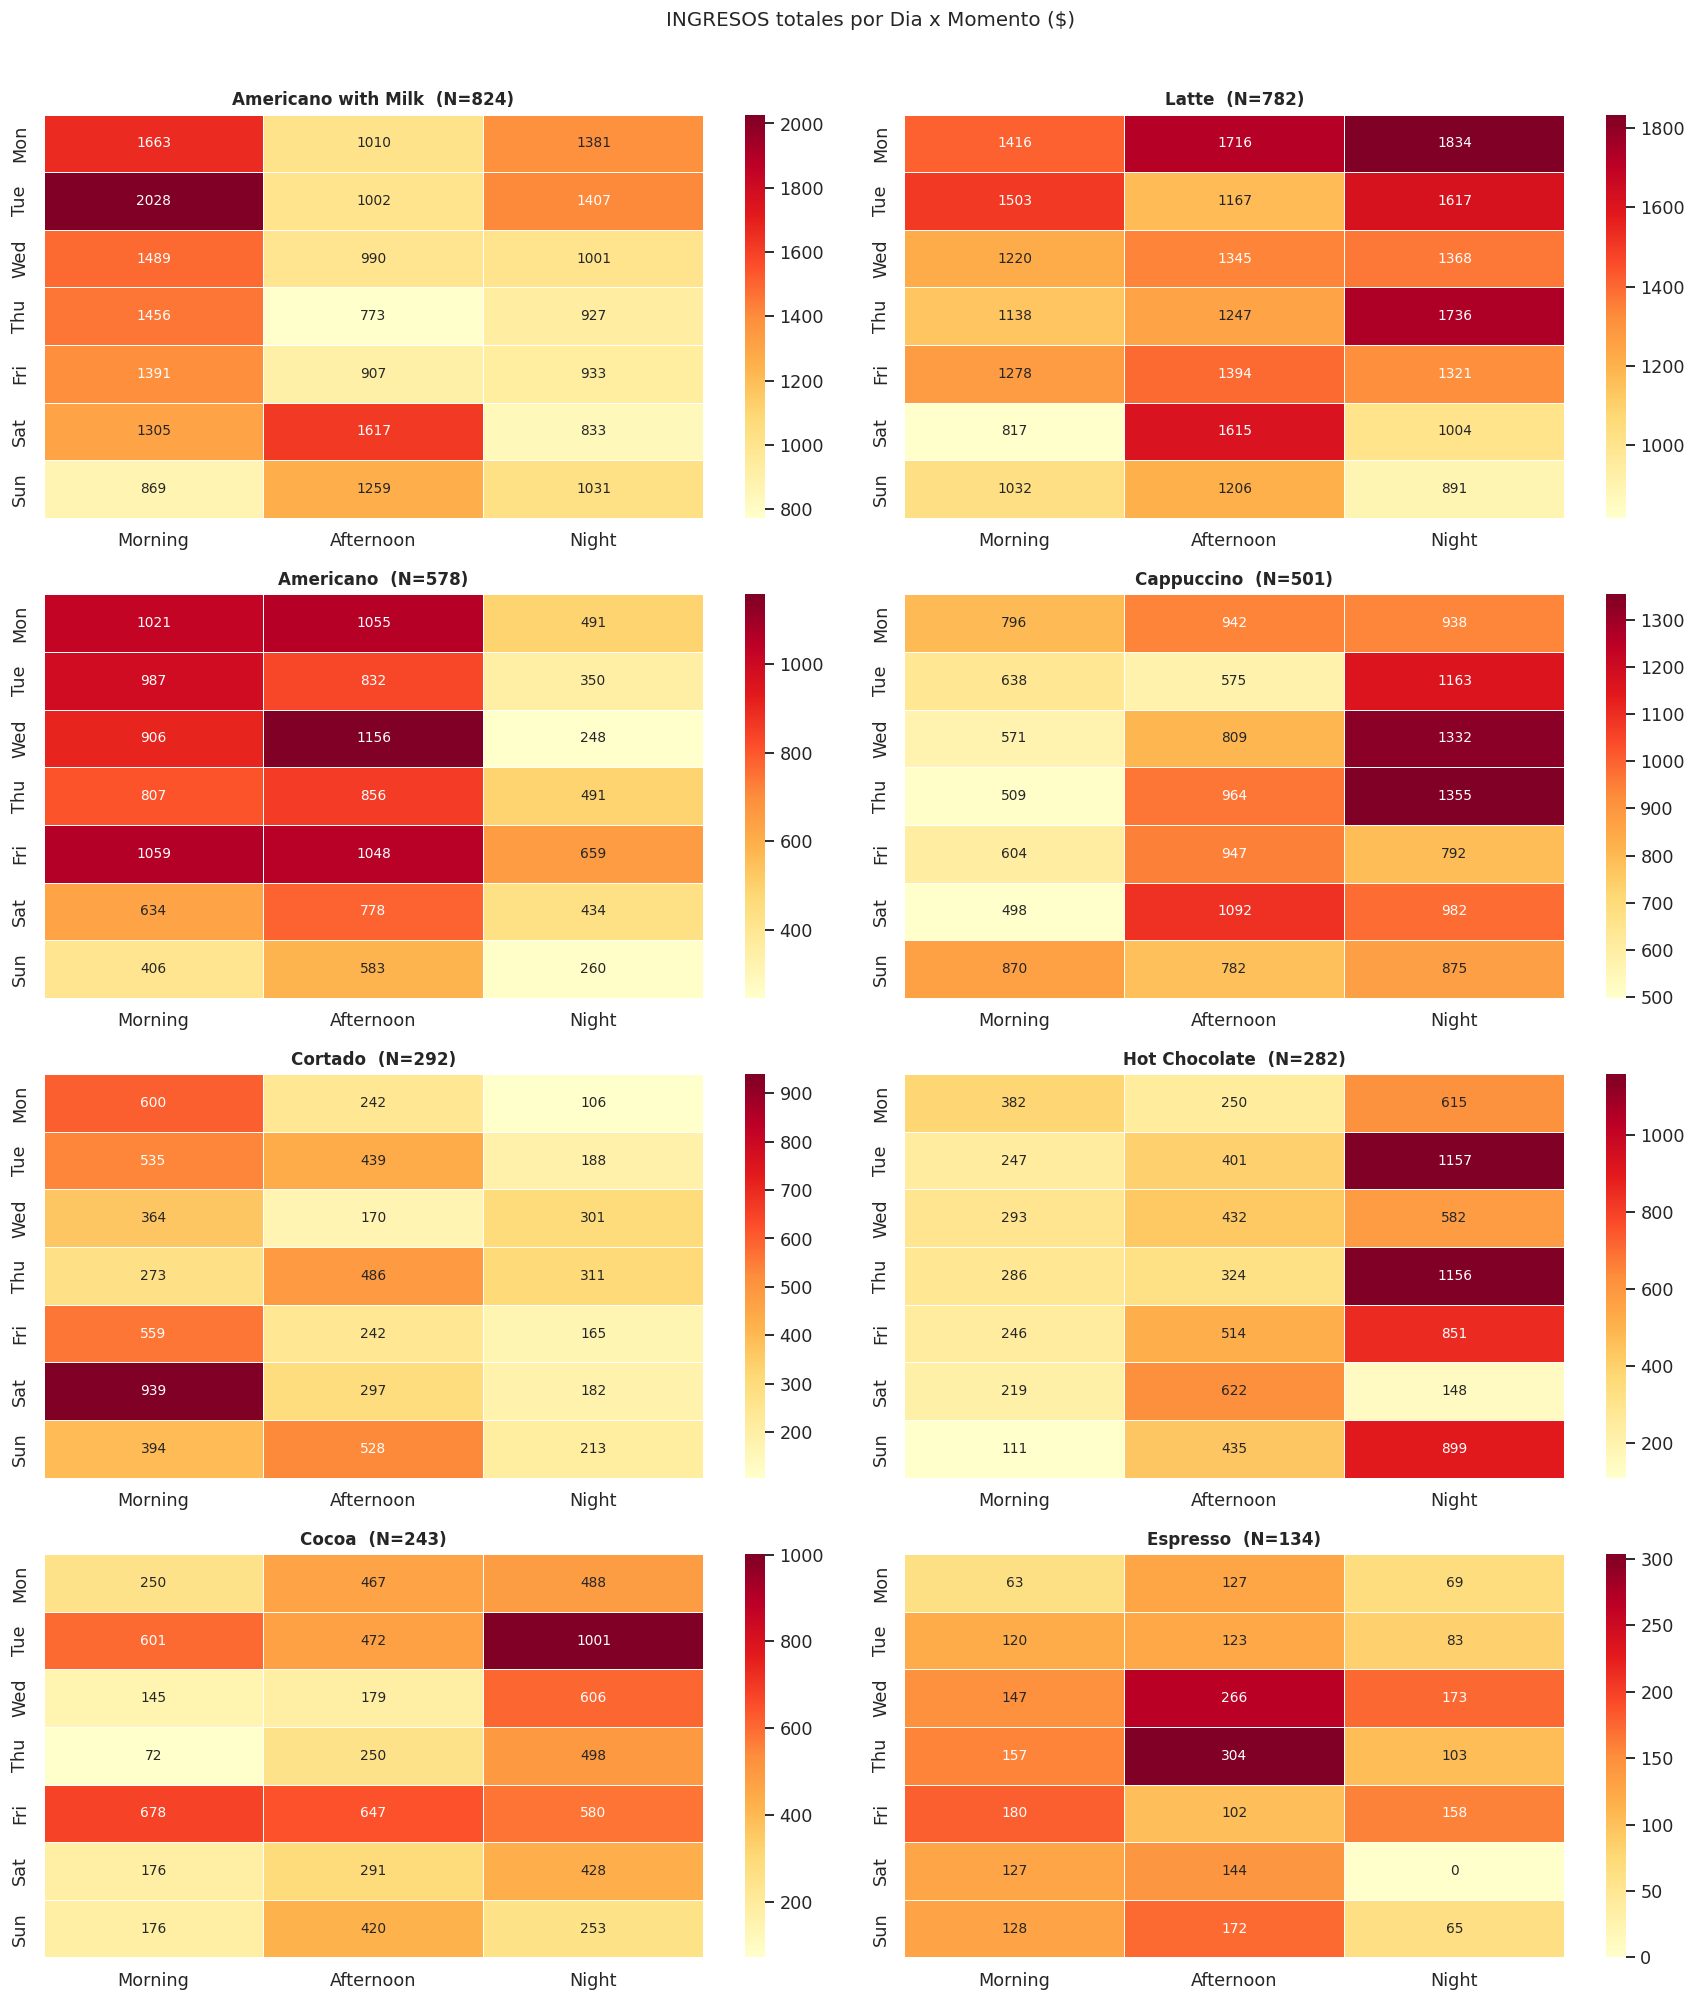

In [4]:
products = df["coffee_name"].value_counts().index.tolist()
ncols = 2
nrows = -(-len(products) // ncols)

# Heatmap de INGRESOS
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4.5))
axes = axes.flatten()

for i, prod in enumerate(products):
    sub = df[df["coffee_name"] == prod]
    pivot = (
        sub.groupby(["Weekday", "Time_of_Day"])["money"]
           .sum()
           .unstack("Time_of_Day")
           .reindex(WEEKDAY_ORDER)
           .reindex(columns=TOD_ORDER)
    )
    sns.heatmap(pivot, ax=axes[i], annot=True, fmt=".0f", cmap="YlOrRd",
                linewidths=0.5, cbar=True, annot_kws={"size": 9})
    axes[i].set_title(f"{prod}  (N={len(sub):,})", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(""); axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("INGRESOS totales por Dia x Momento ($)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

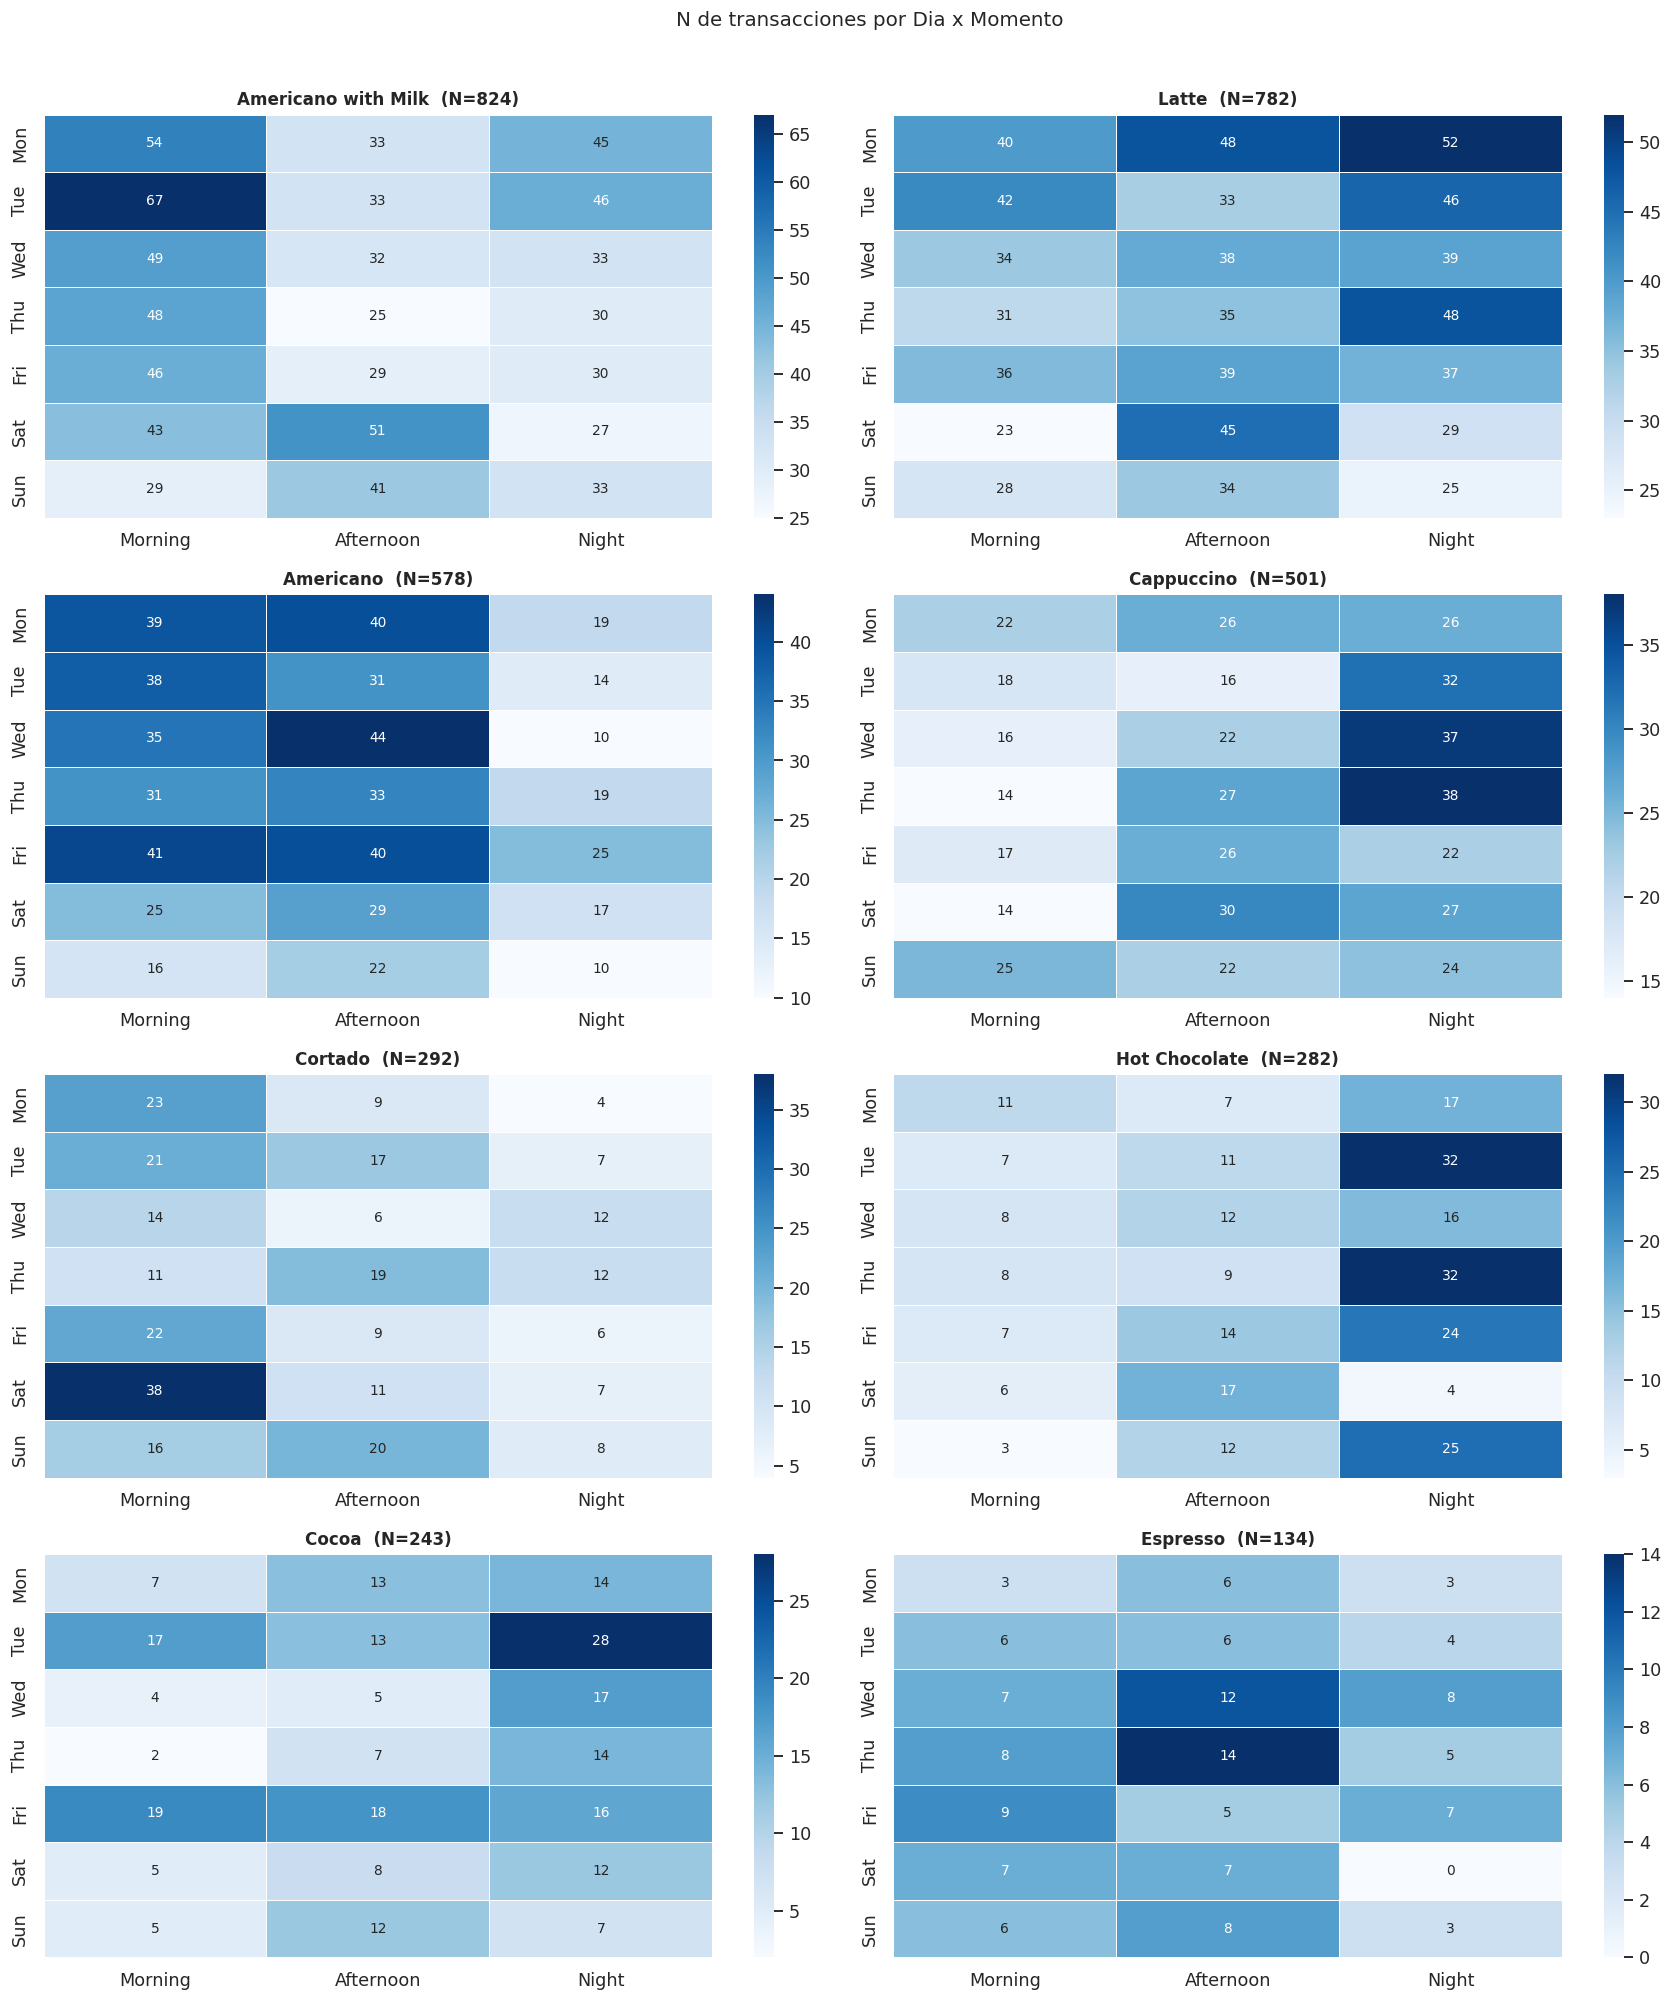

In [5]:
# Heatmap de CANTIDAD (transacciones)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4.5))
axes = axes.flatten()

for i, prod in enumerate(products):
    sub = df[df["coffee_name"] == prod]
    pivot = (
        sub.groupby(["Weekday", "Time_of_Day"])["money"]
           .count()
           .unstack("Time_of_Day")
           .reindex(WEEKDAY_ORDER)
           .reindex(columns=TOD_ORDER)
    )
    sns.heatmap(pivot, ax=axes[i], annot=True, fmt=".0f", cmap="Blues",
                linewidths=0.5, cbar=True, annot_kws={"size": 9})
    axes[i].set_title(f"{prod}  (N={len(sub):,})", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(""); axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("N de transacciones por Dia x Momento", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 5. Evolucion mensual e ingresos por hora

In [6]:
monthly = (
    df.groupby(["year_month", "coffee_name"])["money"]
      .sum().reset_index()
      .assign(year_month=lambda x: x["year_month"].astype(str))
)

fig = px.line(monthly, x="year_month", y="money", color="coffee_name",
              title="Evolucion mensual de ingresos por producto",
              labels={"money": "Ingresos ($)", "year_month": "Mes", "coffee_name": "Producto"},
              color_discrete_sequence=PRODUCT_COLORS)
fig.update_layout(xaxis_tickangle=-45, legend_title="Producto")
fig.show()

In [7]:
hourly = df.groupby(["hour_of_day", "coffee_name"])["money"].sum().reset_index()
fig = px.bar(hourly, x="hour_of_day", y="money", color="coffee_name",
             title="Ingresos por hora del dia",
             labels={"money": "Ingresos ($)", "hour_of_day": "Hora", "coffee_name": "Producto"},
             color_discrete_sequence=PRODUCT_COLORS, barmode="stack")
fig.update_layout(xaxis=dict(dtick=1), legend_title="Producto")
fig.show()

## 6. Modelo de efectos temporales sobre la demanda (OLS)

**Especificacion:**

```
log(qty_d,t,s,a) = alfa + B1*Dia + B2*Momento + B3*Estacion + B4*Ano + error
```

- **Variable dependiente:** `log(cantidad de ventas)` por celda Dia x Momento x Estacion x Ano
- **Regresores:** dummies temporales, todos exogenos — no estan determinados por la demanda
- **Interpretacion:** diferencia porcentual aproximada en demanda vs. referencia (Lunes · Manana · Invierno)
- **Mejoras vs. version anterior:** misma especificacion para todos los productos + C(year) en todos


In [8]:
def analizar_producto(nombre, df, ref_dia="Mon", ref_tod="Morning", ref_season="Winter"):
    """Modelo OLS de efectos temporales: log(qty) ~ Dia + Momento + Estacion + Ano."""
    sub = df[df["coffee_name"] == nombre].copy()
    grp_cols = ["Weekday", "Time_of_Day", "season", "year"]
    model_data = (
        sub.groupby(grp_cols)
           .agg(qty=("money", "count"), revenue=("money", "sum"))
           .reset_index()
    )
    model_data["log_qty"] = np.log(model_data["qty"] + 1)
    formula = (
        f'log_qty ~ '
        f'C(Weekday, Treatment(reference="{ref_dia}")) + '
        f'C(Time_of_Day, Treatment(reference="{ref_tod}")) + '
        f'C(season, Treatment(reference="{ref_season}")) + '
        f'C(year)'
    )
    return smf.ols(formula=formula, data=model_data).fit(), model_data


def extraer_efectos(modelo, nombre):
    """Extrae coeficientes con IC 95% y p-values."""
    out = pd.DataFrame({
        "coef":  modelo.params,
        "lower": modelo.conf_int()[0],
        "upper": modelo.conf_int()[1],
        "p":     modelo.pvalues
    }).drop("Intercept", errors="ignore")
    out["sig"]     = out["p"].apply(lambda p: "***" if p<0.01 else ("**" if p<0.05 else ("*" if p<0.1 else "")))
    out["producto"] = nombre
    return out.reset_index().rename(columns={"index": "variable"})

In [9]:
resultados     = {}
todos_efectos  = []

for prod in products:
    n = (df["coffee_name"] == prod).sum()
    if n < 50:
        print(f"  {prod}: solo {n} obs., omitido")
        continue
    modelo, data = analizar_producto(prod, df)
    resultados[prod] = (modelo, data)
    todos_efectos.append(extraer_efectos(modelo, prod))

    print(f"\n{'='*60}")
    print(f"  {prod} | N celdas: {len(data)} | R2={modelo.rsquared:.3f} | R2-adj={modelo.rsquared_adj:.3f}")
    print(f"{'='*60}")
    print(modelo.summary().tables[1])


  Americano with Milk | N celdas: 168 | R2=0.418 | R2-adj=0.373
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept                                                       2.4223      0.220     11.021      0.000       1.988       2.856
C(Weekday, Treatment(reference="Mon"))[T.Tue]                   0.0258      0.228      0.113      0.910      -0.425       0.476
C(Weekday, Treatment(reference="Mon"))[T.Wed]                  -0.1867      0.228     -0.819      0.414      -0.637       0.264
C(Weekday, Treatment(reference="Mon"))[T.Thu]                  -0.1783      0.228     -0.782      0.435      -0.629       0.272
C(Weekday, Treatment(reference="Mon"))[T.Fri]                  -0.1966      0.228     -0.862      0.390      -0.647       0.254
C(Weekday, Treatment(reference="Mon"))[

## 7. Visualizacion de efectos temporales

In [10]:
all_eff = pd.concat(todos_efectos, ignore_index=True)
temporal = all_eff[all_eff["variable"].str.contains("Weekday|Time_of_Day", regex=True)].copy()

# Limpiar nombres de variables
temporal["label"] = (
    temporal["variable"]
    .str.replace(r"C\(Weekday.*?\)\[T\.", "", regex=True)
    .str.replace(r"C\(Time_of_Day.*?\)\[T\.", "Momento: ", regex=True)
    .str.replace("]", "", regex=False)
)

fig = px.scatter(
    temporal, x="coef", y="label", color="producto",
    facet_col="producto", facet_col_wrap=3,
    title="Efectos temporales sobre log(demanda) — coeficientes OLS con IC 95%",
    labels={"coef": "Coef. vs Lunes/Manana", "label": ""},
    color_discrete_sequence=PRODUCT_COLORS, height=650
)
fig.add_vline(x=0, line_dash="dash", line_color="gray", opacity=0.5)
fig.update_traces(marker=dict(size=8))
fig.update_layout(showlegend=False)
fig.show()
print("Coef positivo = mayor demanda que el dia/momento de referencia (Lunes manana)")

Coef positivo = mayor demanda que el dia/momento de referencia (Lunes manana)


## 8. Tabla de oportunidades de rentabilidad

Cruzamos demanda actual vs. demanda esperada uniforme por slot (Dia x Momento) con el precio promedio del producto. Resultado: ranking de slots con mayor potencial.


In [11]:
slot_stats = (
    df.groupby(["coffee_name", "Weekday", "Time_of_Day"])
      .agg(qty=("money","count"), revenue=("money","sum"), avg_price=("money","mean"))
      .reset_index()
)

total_qty           = slot_stats.groupby("coffee_name")["qty"].transform("sum")
n_slots             = slot_stats.groupby("coffee_name")["qty"].transform("count")
slot_stats["expected"]     = total_qty / n_slots
slot_stats["gap_qty"]      = slot_stats["expected"] - slot_stats["qty"]
slot_stats["gap_revenue"]  = slot_stats["gap_qty"] * slot_stats["avg_price"]
slot_stats["share_pct"]    = slot_stats["qty"] / total_qty * 100

oport = (
    slot_stats[slot_stats["gap_qty"] > 0]
    .sort_values("gap_revenue", ascending=False)
    .head(20)
    [["coffee_name","Weekday","Time_of_Day","qty","expected","gap_qty","avg_price","gap_revenue","share_pct"]]
)
oport.columns = ["Producto","Dia","Momento","Qty actual","Qty esperada",
                 "Brecha (u)","Precio avg ($)","Upside ($)","% demanda"]

print("TOP 20 OPORTUNIDADES — mayor upside potencial de ingresos")
print("(Brecha = Demanda uniforme esperada menos Demanda actual del slot)\n")
display(oport.round(1).reset_index(drop=True)
        .style.background_gradient(subset=["Upside ($)"], cmap="Greens"))

TOP 20 OPORTUNIDADES — mayor upside potencial de ingresos
(Brecha = Demanda uniforme esperada menos Demanda actual del slot)



,Producto,Dia,Momento,Qty actual,Qty esperada,Brecha (u),Precio avg ($),Upside ($),% demanda
0,Latte,Sat,Morning,23,37.200000,14.200000,35.500000,505.700000,2.900000
1,Americano,Sun,Night,10,27.500000,17.500000,26.000000,455.100000,1.700000
2,Americano with Milk,Thu,Afternoon,25,39.200000,14.200000,30.900000,440.500000,3.000000
3,Latte,Sun,Night,25,37.200000,12.200000,35.600000,436.200000,3.200000
4,Americano,Wed,Night,10,27.500000,17.500000,24.800000,434.300000,1.700000
5,Hot Chocolate,Sun,Morning,3,13.400000,10.400000,37.100000,386.600000,1.100000
6,Americano with Milk,Sat,Night,27,39.200000,12.200000,30.900000,377.700000,3.300000
7,Cappuccino,Thu,Morning,14,23.900000,9.900000,36.400000,358.400000,2.800000
8,Cappuccino,Sat,Morning,14,23.900000,9.900000,35.600000,350.400000,2.800000
9,Hot Chocolate,Sat,Night,4,13.400000,9.400000,37.000000,348.700000,1.400000


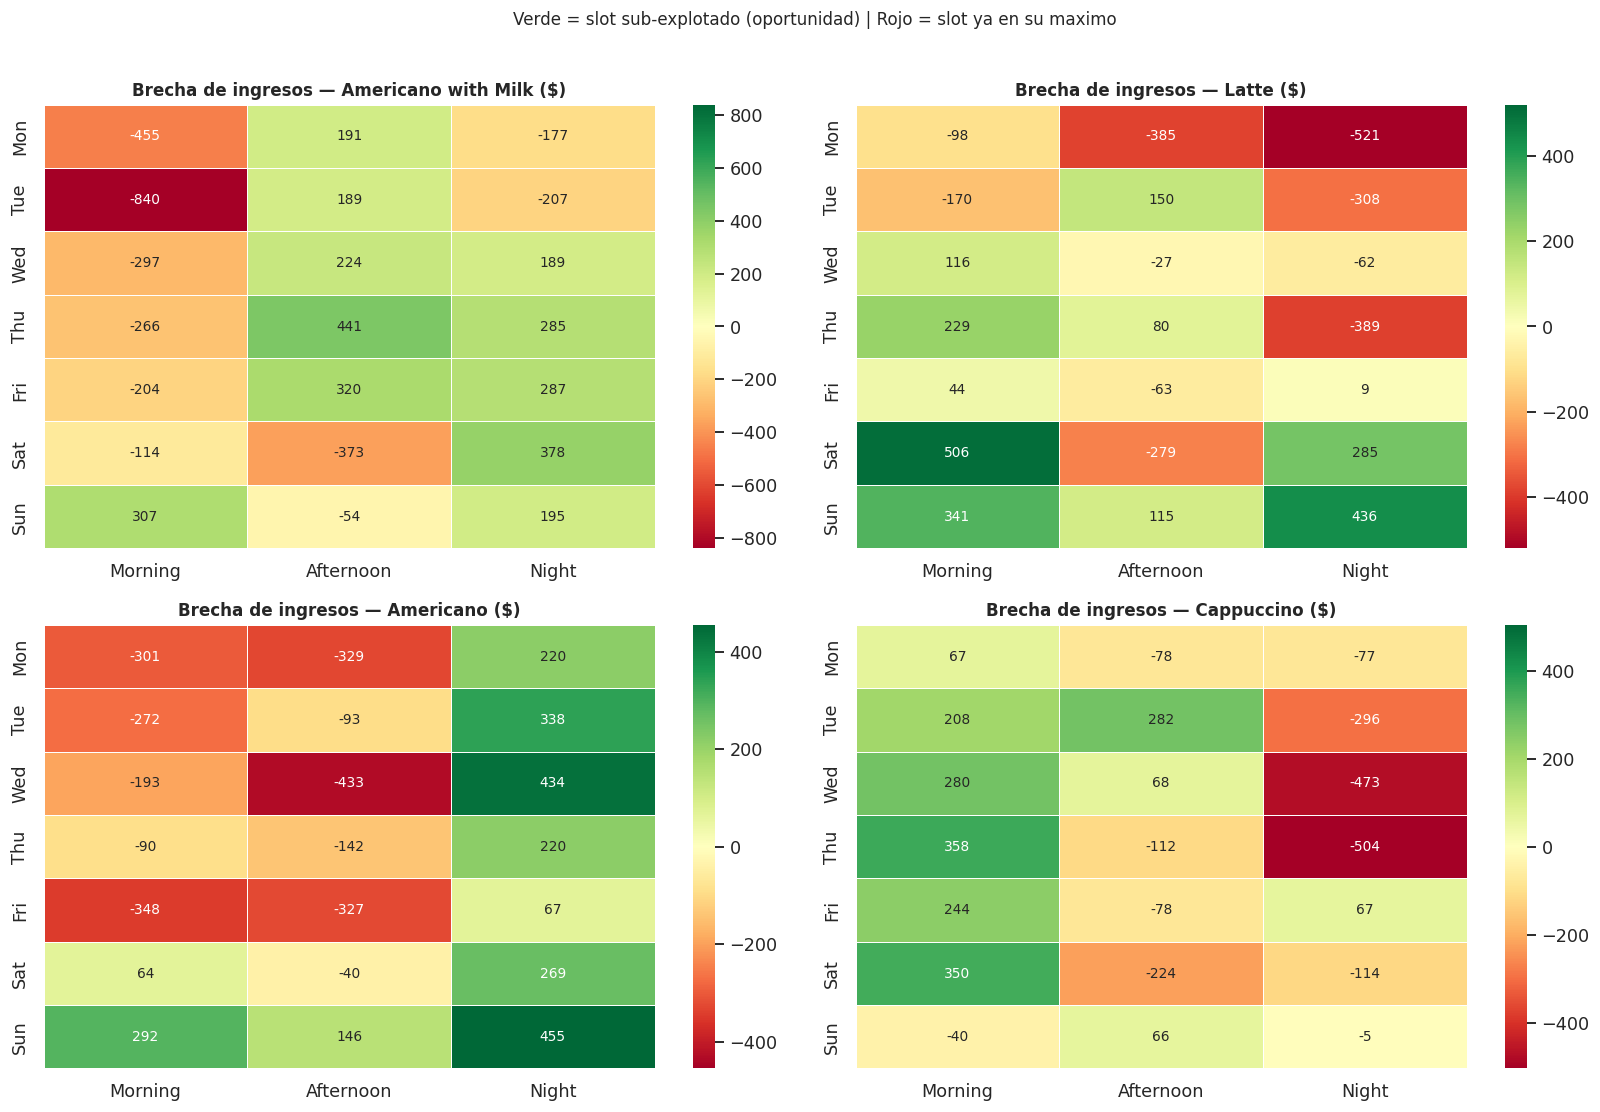

In [12]:
# Heatmap de brechas para los 4 productos principales
top4 = df["coffee_name"].value_counts().head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, prod in enumerate(top4):
    sub = slot_stats[slot_stats["coffee_name"] == prod].copy()
    pivot = (
        sub.set_index(["Weekday", "Time_of_Day"])["gap_revenue"]
           .unstack("Time_of_Day")
           .reindex(WEEKDAY_ORDER)
           .reindex(columns=TOD_ORDER)
    )
    vmax = max(abs(pivot.values[~np.isnan(pivot.values)]))
    sns.heatmap(pivot, ax=axes[i], annot=True, fmt=".0f", cmap="RdYlGn",
                linewidths=0.5, cbar=True, annot_kws={"size": 9},
                center=0, vmin=-vmax, vmax=vmax)
    axes[i].set_title(f"Brecha de ingresos — {prod} ($)", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(""); axes[i].set_ylabel("")

plt.suptitle("Verde = slot sub-explotado (oportunidad) | Rojo = slot ya en su maximo", fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

## 9. Variacion de precios detectada (analisis descriptivo)

Se detecto repricing en agosto 2024. Este ejercicio es **solo descriptivo** — no equivale a elasticidad precio porque el cambio de precio coincide con factores estacionales (confounding) y no fue un experimento aleatorio controlado.


In [13]:
monthly_det = (
    df.groupby(["year_month", "coffee_name"])
      .agg(qty=("money","count"), avg_price=("money","mean"))
      .reset_index()
      .assign(year_month=lambda x: x["year_month"].astype(str))
)

fig = make_subplots(rows=2, cols=2,
    subplot_titles=[f"{p}" for p in top4],
    specs=[[{"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}]])

positions = [(1,1), (1,2), (2,1), (2,2)]
for idx, prod in enumerate(top4):
    r, c = positions[idx]
    sub = monthly_det[monthly_det["coffee_name"] == prod]
    fig.add_trace(go.Bar(x=sub["year_month"], y=sub["qty"],
                         name="Qty", marker_color="lightblue", showlegend=(idx==0)),
                  row=r, col=c, secondary_y=False)
    fig.add_trace(go.Scatter(x=sub["year_month"], y=sub["avg_price"],
                             name="Precio ($)", mode="lines+markers",
                             line=dict(color="red", width=2), showlegend=(idx==0)),
                  row=r, col=c, secondary_y=True)

fig.update_layout(title_text="Cantidad mensual vs. Precio promedio (descripcion)", height=620)
fig.show()
print("Observacion: el repricing de ago-2024 no produjo un rebote claro de volumen.")
print("Esto sugiere demanda relativamente inelastica, pero la evidencia es debil (un evento, confounding estacional).")

Observacion: el repricing de ago-2024 no produjo un rebote claro de volumen.
Esto sugiere demanda relativamente inelastica, pero la evidencia es debil (un evento, confounding estacional).


## 10. Resumen ejecutivo y recomendaciones estrategicas

### Hallazgos principales

| Dimension | Hallazgo |
|-----------|----------|
| **Producto estrella** | Americano with Milk y Latte concentran >44% de ingresos totales |
| **Alto margen, bajo volumen** | Cappuccino y Cocoa: precio promedio ~$36 pero mucho menor volumen |
| **Mejor slot horario** | Morning es el horario lider en la mayoria de productos |
| **Dia mas fuerte** | Martes y jueves manana en Americano with Milk; lunes noche en Latte |
| **Mayor oportunidad** | Domingos y viernes noche muestran brechas en casi todos los productos |
| **Efecto precio** | Evidencia descriptiva debil de sensibilidad; demanda mas explicada por dia/hora |

### Estrategias accionables

**1. Impulsar Cappuccino y Cocoa en tardes de lunes a miercoles**
Slots con brechas positivas y precio alto (~$36). Un combo de 'tarde premium' podria sumar $300-500/semana.

**2. Activar Hot Chocolate en Otono-Invierno**
OLS confirma efectos estacionales. Periodo oct-feb es el mas propicio: comunicacion activa de temporada.

**3. Promocion lunes manana para Americano with Milk**
Martes/jueves son el peak; el lunes muestra brecha. 'Arranca la semana' podria capturar 10-15 unidades adicionales.

**4. Menu nocturno rotativo**
Latte domina noche lun-jue pero deja espacio para Cappuccino. Rotacion por dia puede elevar el ticket promedio nocturno.

**5. Test de repricing controlado**
La evidencia descriptiva sugiere baja elasticidad en productos premium. Una subida moderada en Cappuccino/Cocoa/Hot Chocolate podria mejorar margen sin sacrificar volumen — pero requiere A/B test controlado antes de generalizar.
